<a href="https://colab.research.google.com/github/guimelrene-ui/Sprint-5-Movilidad-urbana-y-productividad-econ-mica/blob/main/S5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.




In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/https://drive.google.com/drive/folders/1GPSL4hWxh8t15ECkyu3CnBz8T5c8yOuv'

In [ ]:
print("Primeras 5 filas del dataset de tráfico:")
display(traffic.head())

Primeras 5 filas del dataset de tráfico:


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
print("\nPrimeras 5 filas del dataset de economía:")
display(eco.head())


Primeras 5 filas del dataset de economía:


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos




In [ ]:
print("Información del DataFrame traffic")
traffic.info()
print("\nPrimeros 3 registros de traffic")
display(traffic.head(3))


Información del DataFrame traffic
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                    

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232



En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo fecha y hora.
- No se encuentran datos ausentes.


In [ ]:
print("\nInformación del DataFrame eco")
eco.info()
print("\nPrimeros 3 registros de eco")
display(eco.head(3))


Información del DataFrame eco
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB

Primeros 3 registros de eco


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, se encuentan las principales ciudades a analizar asi como los paises y los porcentajes de desempleo.
- No se encuentran datos faltantes

### 2.2 Renombrar columnas


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'City' : 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay' : 'jams_delay',
    'TrafficIndexLive' : 'traffic_index_live',
    'JamsLengthInKms' : 'jams_length_kms',
    'JamsCount' : 'jams_count',
    'TrafficIndexWeekAgo' : 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo' : 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins' : 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins' : 'travel_time_hist_per_10kms_mins',
    'MinsDelay' : 'mins_delay'
})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Year' : 'year',
    'City' : 'city',
    'Country': 'country',
    'City GDP/capita' : 'city_gdp_capita',
    'Unemployment %' : 'unemployment_pct',
    'PM2.5 (μg/m³)' : 'pm25',
    'Population (M)' : 'population_m'
    })

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha



In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(
    traffic['update_time_utc'],
    errors='coerce'
)
traffic['update_time_utc_week_ago'] = pd.to_datetime(
    traffic['update_time_utc_week_ago'],
    errors='coerce'
)

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
# city_gdp_capita
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# unemployment_pct
eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .str.replace('%', '', regex=False)   # Elimina el símbolo %
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# population_m
eco['population_m'] = (
    eco['population_m']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Nueva columna
eco['population'] = eco['population_m'] * 1_000_000



# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar



In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()

eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad


In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'])
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10kms_mins' : 'mean',
        'travel_time_hist_per_10kms_mins': 'mean'
    })
    .reset_index()
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México con un retraso total de 2833 minutos


---

## 🧩Paso 5: Unir movilidad y economía




In [ ]:
# Seleccionar columnas clave de tráfico y economía

left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_subset = traffic_city_year_2024[left_cols].copy()
eco_subset = eco_2024[right_cols].copy()

# Unir datasets
merged =  traffic_subset.merge(
    eco_subset,
    on=['city', 'year'],
    how='inner'
)

# Mostrar las primeras 5 filas
display(merged.head())


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones


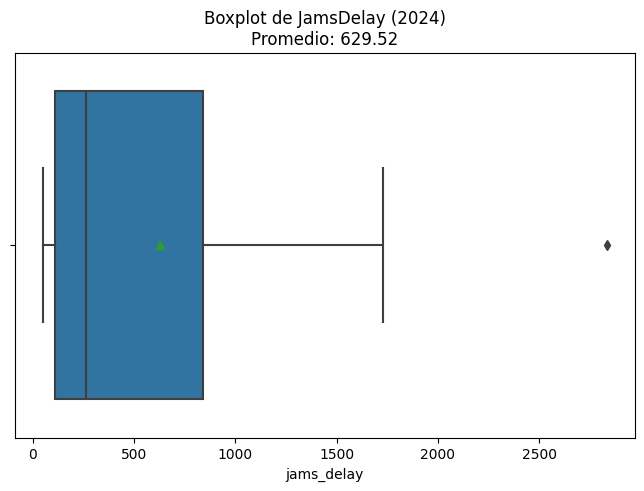

In [ ]:


# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
plt.figure(figsize=(8, 5))
sns.boxplot(x=merged['jams_delay'],showmeans=True)


# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()



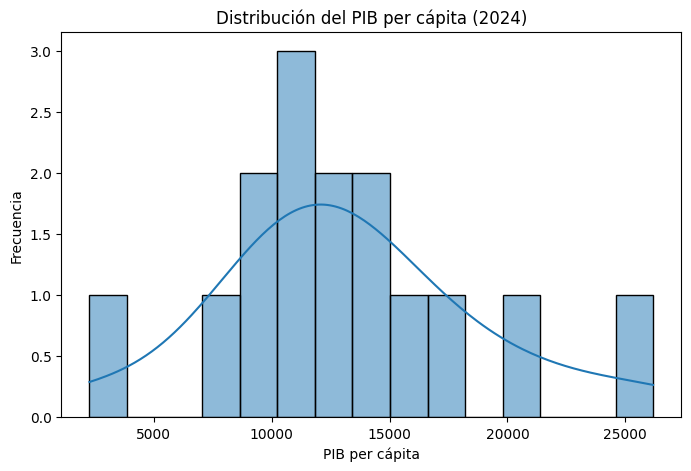

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.figure(figsize=(8, 5))
sns.histplot(merged['city_gdp_capita'], bins=15, kde=True)

plt.title('Distribución del PIB per cápita (2024)')
plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia')
plt.show()


<Figure size 1400x600 with 0 Axes>

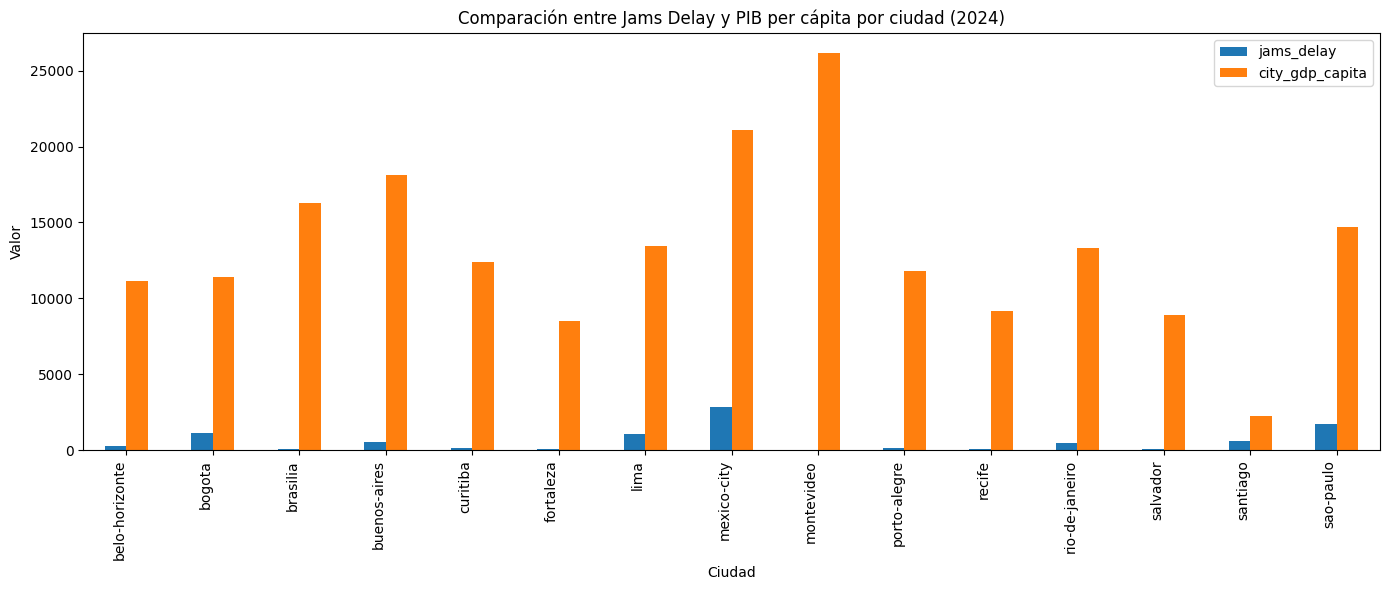

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
comparison = merged[['city', 'jams_delay', 'city_gdp_capita']].copy()

comparison = comparison.set_index('city')

plt.figure(figsize=(14, 6))
comparison.plot(kind='bar', figsize=(14, 6))

plt.title('Comparación entre Jams Delay y PIB per cápita por ciudad (2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valor')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()

plt.show()

### 🧠 **Reflexiona**


Escribe tus comentarios: Al analizar el grafico podemos observar que no hay una relacion clara. Ya que por ejemplo montevideo no muestra un incremento en la congestion aunque se encuentra con un PIB alto. A diferencia la ciudad de Mexico si muestra una congestion alta sin ser el PIB mas alto.


---

## 🧩Paso 7: Exportar y documentar resultados




In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
 Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
El objetivo de este análisis fue evaluar la relación entre la movilidad urbana, medida mediante indicadores de congestión y tiempos de viaje, y la productividad económica, representada principalmente por el PIB per cápita y la tasa de desempleo. Para ello se integraron indicadores de tráfico de TomTom con información económica de la OCDE, con el propósito de identificar ciudades donde inversiones en infraestructura de transporte podrían generar un mayor impacto en la productividad y el bienestar de la población.

**Cobertura de datos:**  
- El análisis considera información correspondiente al año 2024 e incluye 15 ciudades pertenecientes a diversos países de América Latina. Las principales variables analizadas fueron jams_delay, traffic_index_live, tiempos de viaje, PIB per cápita (city_gdp_capita), tasa de desempleo (unemployment_pct) y población.

**Metodología (alto nivel):**  
-Se realizó una limpieza de datos mediante la estandarización de nombres de columnas, conversión de formatos de fecha y variables numéricas, y creación de una variable de población total. Posteriormente se calcularon promedios de los indicadores de tráfico por ciudad y año, y se integraron ambos conjuntos de datos mediante una unión INNER utilizando las variables city y year. Finalmente, se emplearon visualizaciones (boxplots, histogramas y gráficos comparativos) para identificar distribuciones, valores atípicos y tendencias generales

**Hallazgos iniciales:**  
-Los resultados muestran que las ciudades con mayores niveles de congestión no siempre presentan el menor PIB per cápita; sin embargo, sí existen casos donde una alta congestión coincide con indicadores económicos relativamente débiles. Bogotá destaca por combinar una congestión muy elevada (1,141.6 minutos de retraso promedio), un PIB per cápita de 11,442 y una tasa de desempleo del 10 %, la más alta entre las ciudades analizadas. En comparación, Lima presenta una congestión similar, pero un PIB per cápita mayor (13,472) y menor desempleo (6.5 %), mientras que Buenos Aires registra menor congestión y un PIB per cápita considerablemente superior (18,117). También se identifican valores atípicos como Ciudad de México, que presenta la mayor congestión del conjunto, aunque mantiene un PIB per cápita relativamente alto.

**Recomendaciones**  
-Se recomienda priorizar Bogotá como candidata para inversiones en infraestructura de transporte, ya que combina altos niveles de congestión con indicadores económicos menos favorables, lo que sugiere un mayor potencial de mejora mediante proyectos de movilidad. Asimismo, conviene realizar un análisis más profundo en Ciudad de México debido a su nivel excepcional de congestión y revisar casos atípicos como Santiago, cuyos indicadores económicos presentan valores que podrían requerir validación de la fuente de datos antes de extraer conclusiones definitivas. Finalmente, se recomienda complementar este estudio con análisis de correlación y modelos estadísticos para cuantificar con mayor precisión el impacto de la movilidad sobre la productividad económica.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?
-- Con base en los datos analizados, Bogotá es la ciudad que mejor cumple con este criterio. Presenta uno de los niveles de congestión más altos del conjunto (1,141.6), un PIB per cápita relativamente bajo (11,442) y la mayor tasa de desempleo (10 %) entre las ciudades evaluadas. Estos resultados sugieren que Bogotá debería considerarse una ciudad prioritaria para inversiones en infraestructura de transporte, ya que una mejora en la movilidad podría contribuir a incrementar la productividad económica y la calidad de vida de sus habitantes.
